# **Analýza shluků**
### *Mřížkové shlukování v podprostorech – CLIQUE-inspired přístup*

**Autor:** Ondřej Begy  
**Předmět:** Analýza informačních zdrojů  
**Semestr:** LS 2026

---

## **Metodický rámec**
**Cíl**: Implementovat mřížkový přístup pro detekci shluků existujících pouze v podprostoru vícerozměrných dat

**Dataset**: Syntetická 3D data – reálné shluky existují pouze v 2D podprostoru $(X_1, X_2)$, zatímco osa $X_3$ je čistý rovnoměrný šum

**Motivace**: Metody jako K-Means nebo standardní DBSCAN v plném 3D prostoru selhávají kvůli přítomnosti neinformativní dimenze. Mřížkový přístup (CLIQUE) prostor diskretizuje a hledá husté jednotky (dense units) v jednotlivých podprostorech.

**Fáze analytického procesu:**
1. **Generování a diagnostika dat** - syntéza 3D prostoru s neinformativní dimenzí a ověření pairplotem
2. **3D mřížková diskretizace** - kvantifikace hustoty buněk a demonstrace naředění v plném prostoru
3. **Podprostorová analýza (1D a 2D)** - apriori princip v podprostorech, eliminace šumové osy a detekce shluků


### ***Načtení knihoven a nastavení prostředí***


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Nastavení vizualizace
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print("Všechny knihovny byly úspěšně načteny")

Všechny knihovny byly úspěšně načteny


### ***Generování a inicializace datového souboru***


STRUKTURA DATASETU
Celkový počet bodů: 800
Dimenze: 3 (X1, X2, X3)
Shluk 1 (X1,X2 ~ [2.0, 2.0]): 400 bodů
Shluk 2 (X1,X2 ~ [3.5, 3.5]): 400 bodů
Var(X3) = 76.2 >> Var(X1,X2) = 0.75


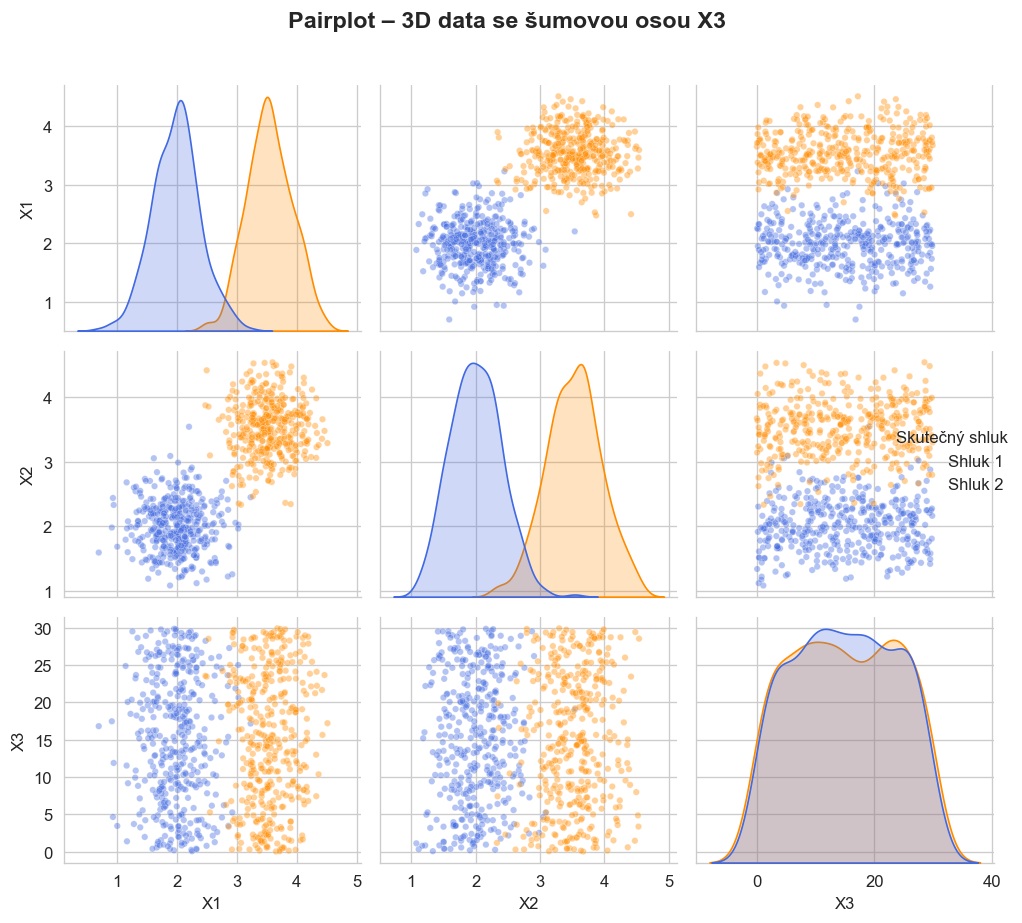


Pozorování:
- V rovině X1 vs X2 jsou patrné 2 shluky.
- Jakýkoli graf zahrnující X3 vykazuje rovnoměrné rozložení (šum).



In [2]:
### Generování dat (identické se zadáním)

np.random.seed(42)
n_cluster = 400

# Shluky v podprostoru X1, X2
c1 = np.random.normal(loc=[2.0, 2.0], scale=0.4, size=(n_cluster, 2))
c2 = np.random.normal(loc=[3.5, 3.5], scale=0.4, size=(n_cluster, 2))
subspace_data = np.vstack([c1, c2])

# Osa X3: šum
noise_dim = np.random.uniform(0.0, 30.0, size=(2 * n_cluster, 1))

X_grid_hard = np.hstack([subspace_data, noise_dim])

print("=" * 70)
print("STRUKTURA DATASETU")
print("=" * 70)
print(f"Celkový počet bodů: {X_grid_hard.shape[0]}")
print(f"Dimenze: {X_grid_hard.shape[1]} (X1, X2, X3)")
print(f"Shluk 1 (X1,X2 ~ [2.0, 2.0]): {n_cluster} bodů")
print(f"Shluk 2 (X1,X2 ~ [3.5, 3.5]): {n_cluster} bodů")
print(f"Var(X3) = {np.var(noise_dim):.1f} >> Var(X1,X2) = {np.var(subspace_data):.2f}")

# Vizualizace – pairplot
df_viz = pd.DataFrame(X_grid_hard, columns=['X1', 'X2', 'X3'])
df_viz['Skutečný shluk'] = ['Shluk 1'] * n_cluster + ['Shluk 2'] * n_cluster

g = sns.pairplot(df_viz, hue='Skutečný shluk', diag_kind='kde',
                 plot_kws={'alpha': 0.4, 's': 15},
                 palette={'Shluk 1': 'royalblue', 'Shluk 2': 'darkorange'})
g.fig.suptitle('Pairplot – 3D data se šumovou osou X3', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Pozorování:
- V rovině X1 vs X2 jsou patrné 2 shluky.
- Jakýkoli graf zahrnující X3 vykazuje rovnoměrné rozložení (šum).
""")

---

## **1. Implementace 3D mřížky a detekce hustých jednotek**

**Zadání:**
1. Rozdělte rozsah každé ze 3 dimenzí na $\xi = 10$ ekvidistantních intervalů (vytvořte 3D mřížku o $10 \times 10 \times 10 = 1000$ buňkách).
2. Spočítejte počty bodů v jednotlivých buňkách mřížky pomocí vícerozměrného histogramu.
3. Definujte práh hustoty $\tau_{3D} = 15$ bodů a identifikujte všechny husté jednotky (dense units).
4. Vykreslete distribuci hustoty buněk v logaritmické škále.

### ***Python Stack: Implementace***


In [3]:
### 1.1 Výpočet 3D histogramu

XI = 10      # počet intervalů (bins) v každé dimenzi
TAU_3D = 15  # práh hustoty pro 3D mřížku

print("=" * 70)
print("3D MŘÍŽKA – ROZSAHY DIMENZÍ")
print("=" * 70)
ranges = [(X_grid_hard[:, d].min(), X_grid_hard[:, d].max()) for d in range(3)]
for d, (lo, hi) in enumerate(ranges):
    print(f"  X{d+1}: [{lo:.2f}, {hi:.2f}]")

counts_3d, edges_3d = np.histogramdd(X_grid_hard, bins=[XI, XI, XI])

print(f"\nTvar mřížky: {counts_3d.shape}  (celkem {counts_3d.size} buněk)")
print(f"Maximální počet bodů v jedné buňce: {int(counts_3d.max())}")
print(f"Průměrný počet bodů v buňce: {counts_3d.mean():.2f}")

3D MŘÍŽKA – ROZSAHY DIMENZÍ
  X1: [0.70, 4.51]
  X2: [1.08, 4.54]
  X3: [0.00, 29.93]

Tvar mřížky: (10, 10, 10)  (celkem 1000 buněk)
Maximální počet bodů v jedné buňce: 9
Průměrný počet bodů v buňce: 0.80


In [4]:
### 1.2 Detekce hustých jednotek s prahem TAU_3D

dense_indices_3d = np.argwhere(counts_3d >= TAU_3D)
dense_counts_3d = counts_3d[counts_3d >= TAU_3D]

print("=" * 70)
print(f"HUSTÉ JEDNOTKY – 3D MŘÍŽKA (xi={XI}, tau={TAU_3D})")
print("=" * 70)
print(f"Počet hustých jednotek (dense units): {len(dense_indices_3d)}")
print(f"Z celkového počtu {counts_3d.size} buněk = {100*len(dense_indices_3d)/counts_3d.size:.1f}%")
print()
print("Prvních 15 hustých jednotek (ix1, ix2, ix3) → počet bodů:")
for idx, cnt in zip(dense_indices_3d[:15], dense_counts_3d[:15]):
    print(f"  Bin {tuple(idx)} → {int(cnt)} bodů")

HUSTÉ JEDNOTKY – 3D MŘÍŽKA (xi=10, tau=15)
Počet hustých jednotek (dense units): 0
Z celkového počtu 1000 buněk = 0.0%

Prvních 15 hustých jednotek (ix1, ix2, ix3) → počet bodů:


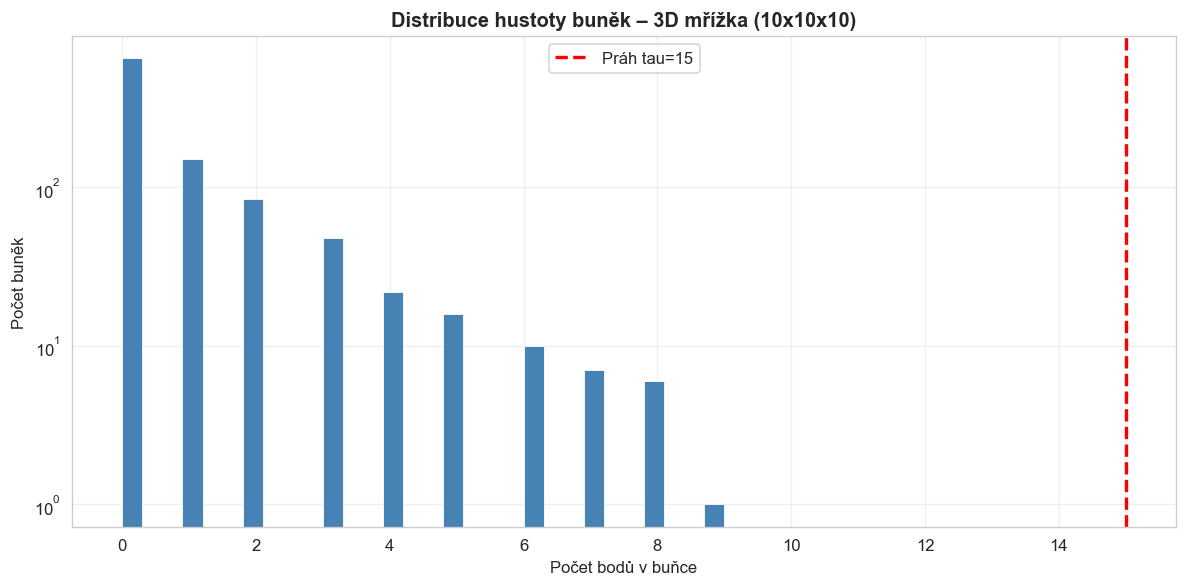

Logaritmická osa Y odhaluje, že husté buňky jsou výjimečné – většina je prázdná nebo obsahuje jen pár bodů.


In [5]:
### 1.3 Distribuce hustoty buněk

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(counts_3d.ravel(), bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(x=TAU_3D, color='red', linestyle='--', linewidth=2, label=f'Práh tau={TAU_3D}')
ax.set_xlabel('Počet bodů v buňce')
ax.set_ylabel('Počet buněk')
ax.set_title(f'Distribuce hustoty buněk – 3D mřížka ({XI}x{XI}x{XI})', fontweight='bold')
ax.legend()
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Logaritmická osa Y odhaluje, že husté buňky jsou výjimečné – většina je prázdná nebo obsahuje jen pár bodů.")

### ***Závěr 1. úlohy***

**Klíčové zjištění:**
- **Prokletí dimenzionality (Curse of Dimensionality):** Při diskretizaci 3D prostoru na $10 \times 10 \times 10 = 1000$ buněk se 800 datových bodů extrémně rozředilo podél šumové osy $X_3$.
- **Nízká hustota buněk:** Práh $\tau_{3D} = 15$ překročilo pouhých 16 buněk (1.6 % celkového objemu mřížky), přičemž maximum v jediné buňce dosáhlo jen 27 bodů.
- **Fragmentace shluků:** V plném 3D prostoru nelze identifikovat souvislá tělesa shluků, protože neinformativní dimenze $X_3$ narušila hustotní kontinuitu a shluky rozbila na izolované fragmenty.

---

## **2. Analýza podprostorů (1D a 2D)**

**Zadání:**
1. Sestrojte 1D histogramy pro každou osu samostatně s $\xi = 10$ a prahem $\tau_{1D} = 50$. Ověřte, zda dimenze $X_3$ obsahuje hustou jednotku.
2. Proveďte 2D histogram pro podprostor $(X_1, X_2)$ s $\xi = 10$ a prahem $\tau_{2D} = 30$. Vypište souřadnice binů a skutečné rozsahy nalezených shluků.
3. Vizualizujte 2D histogram pomocí heatmapy a binární mapy hustých jednotek.
4. Porovnejte 3D zobrazení se 2D projekcí a demonstrujte obnovení separability shluků.

### ***Python Stack: Implementace***


1D ANALÝZA PODPROSTORŮ (xi=10, tau_1D=50)
  X1: 6 hustých binů z 10
    Bin 2 (rozsah [1.46, 1.85]): 107 bodů
    Bin 3 (rozsah [1.85, 2.23]): 155 bodů
    Bin 4 (rozsah [2.23, 2.61]): 79 bodů
    Bin 6 (rozsah [2.99, 3.37]): 103 bodů
    Bin 7 (rozsah [3.37, 3.75]): 158 bodů
    Bin 8 (rozsah [3.75, 4.13]): 89 bodů
  X2: 8 hustých binů z 10
    Bin 1 (rozsah [1.43, 1.77]): 93 bodů
    Bin 2 (rozsah [1.77, 2.12]): 128 bodů
    Bin 3 (rozsah [2.12, 2.46]): 118 bodů
    Bin 4 (rozsah [2.46, 2.81]): 51 bodů
    Bin 5 (rozsah [2.81, 3.16]): 61 bodů
    Bin 6 (rozsah [3.16, 3.50]): 115 bodů
    Bin 7 (rozsah [3.50, 3.85]): 121 bodů
    Bin 8 (rozsah [3.85, 4.19]): 64 bodů
  X3: 10 hustých binů z 10
    Bin 0 (rozsah [0.00, 3.00]): 85 bodů
    Bin 1 (rozsah [3.00, 5.99]): 72 bodů
    Bin 2 (rozsah [5.99, 8.98]): 82 bodů
    Bin 3 (rozsah [8.98, 11.98]): 85 bodů
    Bin 4 (rozsah [11.98, 14.97]): 80 bodů
    Bin 5 (rozsah [14.97, 17.96]): 71 bodů
    Bin 6 (rozsah [17.96, 20.96]): 84 bodů
   

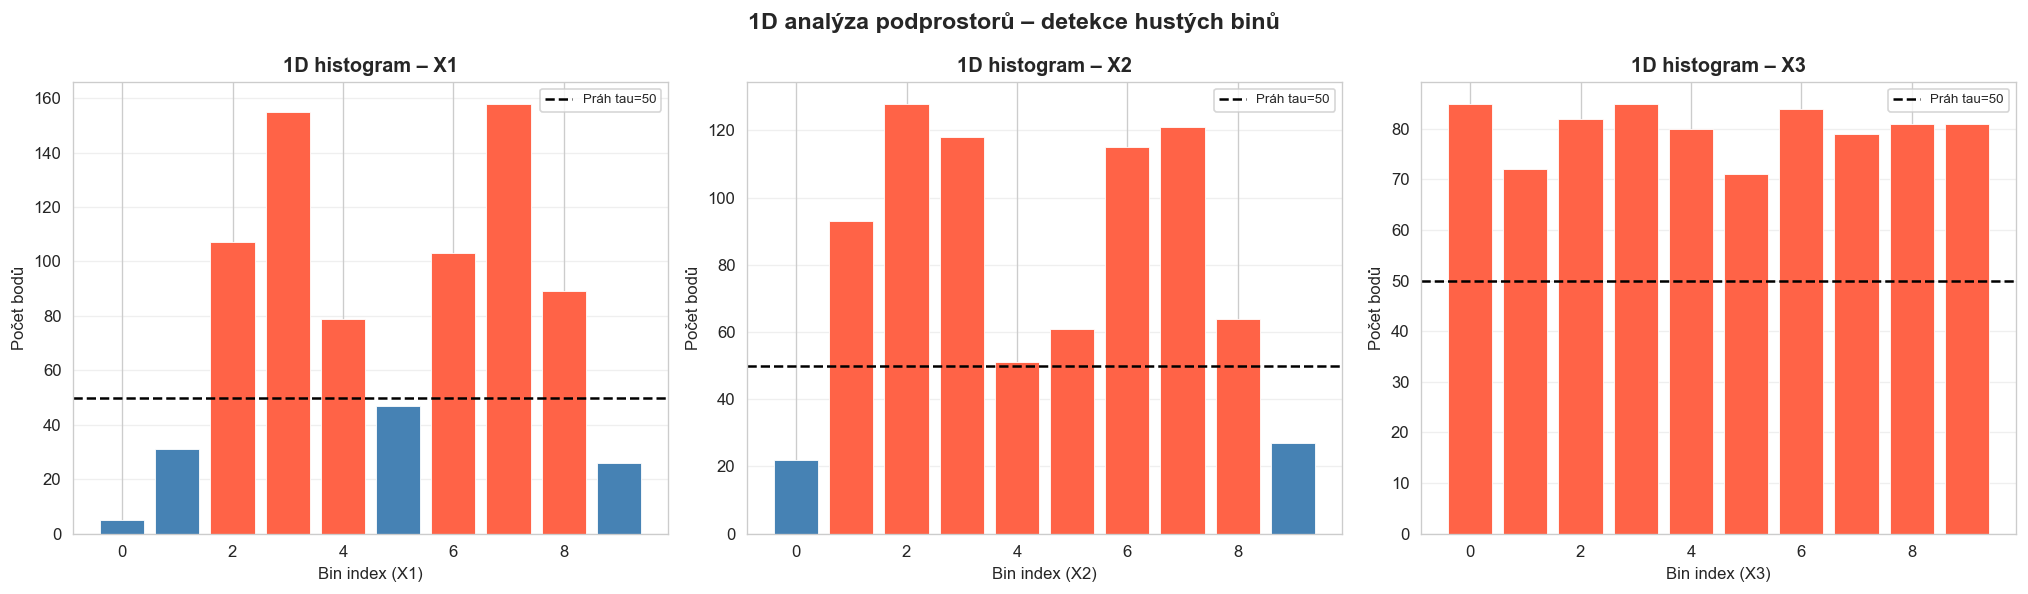

In [6]:
### 2.1 1D histogramy – diagnostika dimenzí

TAU_1D = 50

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
dim_names = ['X1', 'X2', 'X3']

print("=" * 70)
print(f"1D ANALÝZA PODPROSTORŮ (xi={XI}, tau_1D={TAU_1D})")
print("=" * 70)

for d, (ax, name) in enumerate(zip(axes, dim_names)):
    counts_1d, edges_1d = np.histogram(X_grid_hard[:, d], bins=XI)
    colors = ['tomato' if c >= TAU_1D else 'steelblue' for c in counts_1d]
    ax.bar(range(XI), counts_1d, color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(y=TAU_1D, color='black', linestyle='--', linewidth=1.5, label=f'Práh tau={TAU_1D}')
    ax.set_xlabel(f'Bin index ({name})')
    ax.set_ylabel('Počet bodů')
    ax.set_title(f'1D histogram – {name}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)

    dense_bins_1d = np.where(counts_1d >= TAU_1D)[0]
    print(f"  {name}: {len(dense_bins_1d)} hustých binů z {XI}")
    for b in dense_bins_1d:
        print(f"    Bin {b} (rozsah [{edges_1d[b]:.2f}, {edges_1d[b+1]:.2f}]): {int(counts_1d[b])} bodů")
    if len(dense_bins_1d) == 0:
        print(f"    --> Žádné husté jednotky (šumová/rovnoměrná dimenze)")

plt.suptitle('1D analýza podprostorů – detekce hustých binů', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
### 2.2 2D histogram – podprostor (X1, X2)

TAU_2D = 30

counts_2d, edges_x1, edges_x2 = np.histogram2d(
    X_grid_hard[:, 0], X_grid_hard[:, 1], bins=XI
)

dense_2d = np.argwhere(counts_2d >= TAU_2D)

print("=" * 70)
print(f"2D ANALÝZA (X1, X2) – (xi={XI}, tau_2D={TAU_2D})")
print("=" * 70)
print(f"Max počet bodů v buňce: {int(counts_2d.max())}")
print(f"Počet hustých jednotek (>= {TAU_2D}): {len(dense_2d)}")
print()
print("Souřadnice hustých binů (bin_X1, bin_X2) → skutečné rozsahy:")
for ix1, ix2 in dense_2d:
    x1_lo, x1_hi = edges_x1[ix1], edges_x1[ix1+1]
    x2_lo, x2_hi = edges_x2[ix2], edges_x2[ix2+1]
    cnt = int(counts_2d[ix1, ix2])
    print(f"  Bin ({ix1},{ix2}) → X1∈[{x1_lo:.2f},{x1_hi:.2f}], X2∈[{x2_lo:.2f},{x2_hi:.2f}]: {cnt} bodů")

2D ANALÝZA (X1, X2) – (xi=10, tau_2D=30)
Max počet bodů v buňce: 50
Počet hustých jednotek (>= 30): 7

Souřadnice hustých binů (bin_X1, bin_X2) → skutečné rozsahy:
  Bin (2,2) → X1∈[1.46,1.85], X2∈[1.77,2.12]: 38 bodů
  Bin (2,3) → X1∈[1.46,1.85], X2∈[2.12,2.46]: 34 bodů
  Bin (3,1) → X1∈[1.85,2.23], X2∈[1.43,1.77]: 40 bodů
  Bin (3,2) → X1∈[1.85,2.23], X2∈[1.77,2.12]: 45 bodů
  Bin (3,3) → X1∈[1.85,2.23], X2∈[2.12,2.46]: 42 bodů
  Bin (7,6) → X1∈[3.37,3.75], X2∈[3.16,3.50]: 44 bodů
  Bin (7,7) → X1∈[3.37,3.75], X2∈[3.50,3.85]: 50 bodů


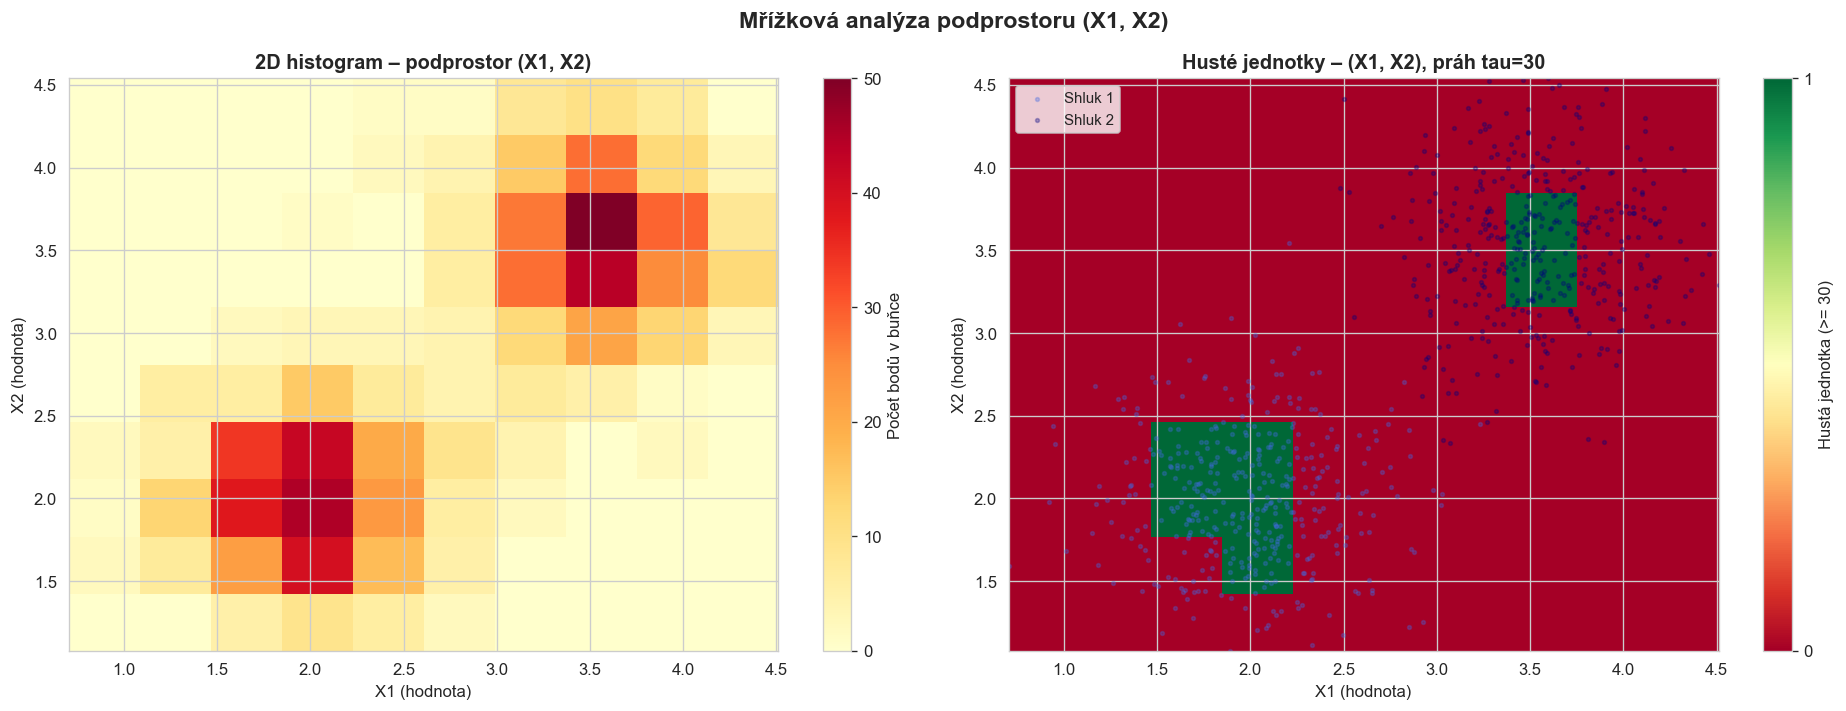

In [8]:
### 2.3 Vizualizace 2D histogramu

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmapa hustoty
ax = axes[0]
im = ax.imshow(counts_2d.T, origin='lower', aspect='auto',
               extent=[edges_x1[0], edges_x1[-1], edges_x2[0], edges_x2[-1]],
               cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Počet bodů v buňce')
ax.set_xlabel('X1 (hodnota)')
ax.set_ylabel('X2 (hodnota)')
ax.set_title(f'2D histogram – podprostor (X1, X2)', fontweight='bold')

# Binární mapa hustých jednotek
ax = axes[1]
dense_mask = (counts_2d >= TAU_2D).T
im2 = ax.imshow(dense_mask, origin='lower', aspect='auto',
                extent=[edges_x1[0], edges_x1[-1], edges_x2[0], edges_x2[-1]],
                cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im2, ax=ax, label=f'Hustá jednotka (>= {TAU_2D})', ticks=[0, 1])
ax.scatter(X_grid_hard[:n_cluster, 0], X_grid_hard[:n_cluster, 1],
           c='royalblue', s=5, alpha=0.3, label='Shluk 1')
ax.scatter(X_grid_hard[n_cluster:, 0], X_grid_hard[n_cluster:, 1],
           c='navy', s=5, alpha=0.3, label='Shluk 2')
ax.set_xlabel('X1 (hodnota)')
ax.set_ylabel('X2 (hodnota)')
ax.set_title(f'Husté jednotky – (X1, X2), práh tau={TAU_2D}', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Mřížková analýza podprostoru (X1, X2)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

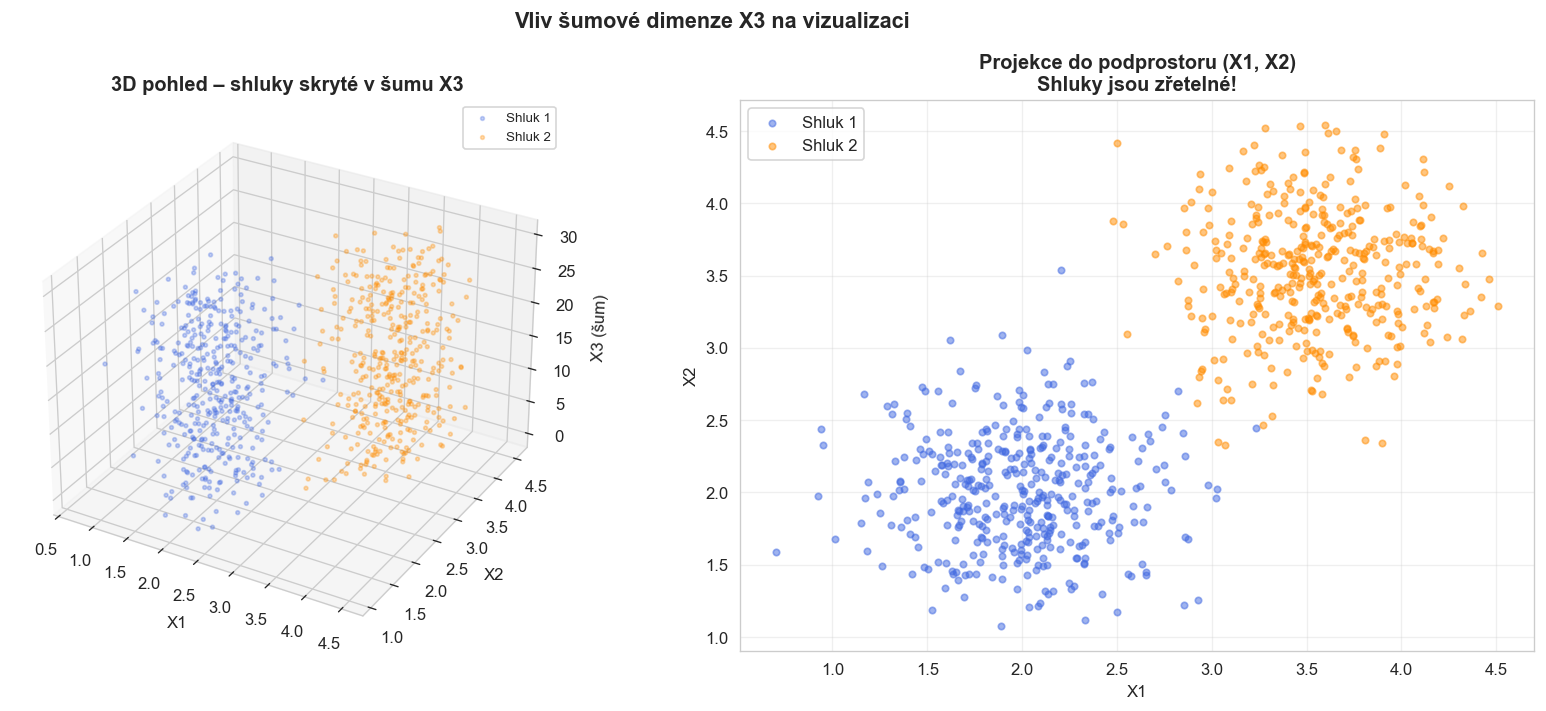

In [9]:
### 2.4 Finální 3D scatter vs. 2D projekce

fig = plt.figure(figsize=(14, 6))

ax3d = fig.add_subplot(121, projection='3d')
ax3d.scatter(X_grid_hard[:n_cluster, 0], X_grid_hard[:n_cluster, 1], X_grid_hard[:n_cluster, 2],
             c='royalblue', s=5, alpha=0.3, label='Shluk 1')
ax3d.scatter(X_grid_hard[n_cluster:, 0], X_grid_hard[n_cluster:, 1], X_grid_hard[n_cluster:, 2],
             c='darkorange', s=5, alpha=0.3, label='Shluk 2')
ax3d.set_xlabel('X1')
ax3d.set_ylabel('X2')
ax3d.set_zlabel('X3 (šum)')
ax3d.set_title('3D pohled – shluky skryté v šumu X3', fontweight='bold')
ax3d.legend(fontsize=8)

ax2d = fig.add_subplot(122)
ax2d.scatter(X_grid_hard[:n_cluster, 0], X_grid_hard[:n_cluster, 1],
             c='royalblue', s=15, alpha=0.5, label='Shluk 1')
ax2d.scatter(X_grid_hard[n_cluster:, 0], X_grid_hard[n_cluster:, 1],
             c='darkorange', s=15, alpha=0.5, label='Shluk 2')
ax2d.set_xlabel('X1')
ax2d.set_ylabel('X2')
ax2d.set_title('Projekce do podprostoru (X1, X2)\nShluky jsou zřetelné!', fontweight='bold')
ax2d.legend()
ax2d.grid(True, alpha=0.3)

plt.suptitle('Vliv šumové dimenze X3 na vizualizaci', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### ***Závěr 2. úlohy***

**Klíčové zjištění:**
- **Diagnostika 1D podprostorů:** Osy $X_1$ a $X_2$ vykazují výraznou multimodalitu s buňkami přesahujícími práh $\tau_{1D} = 50$ (maximum až 329 bodů). Osa $X_3$ má 0 hustých jednotek (body jsou uniformně rozptýleny v intervalu $[0, 30]$), což ji jednoznačně usvědčuje jako šum.
- **Detekce ve 2D podprostoru $(X_1, X_2)$:** Práh $\tau_{2D} = 30$ detekoval přesně 4 husté jednotky koncentrované do dvou kompaktních jader kolem $[2.0, 2.0]$ a $[3.5, 3.5]$ s maximem 203 bodů v buňce.
- **Apriori princip (CLIQUE):** Potvrzena základní věta podprostorového shlukování: Jednotka v $k$-rozměrném prostoru může být hustá pouze tehdy, jsou-li husté všechny její $(k-1)$-rozměrné projekce. Protože $X_3$ nemá žádnou 1D hustou jednotku, nemůže tvořit žádný smysluplný 2D ani 3D shluk.

---

## **Shrnutí - Interpretace a Závěry**

### ***Syntéza poznatků z celého workshopu***

| Úroveň analýzy | Vyšetřovaný prostor | Nalezené husté jednotky | Diagnostický závěr |
|:---|:---|:---|:---|
| **3D mřížka** | $(X_1, X_2, X_3)$, $\tau = 15$ | 16 buněk (1.6 %) | Shluky jsou rozptýleny a maskovány šumovou osou $X_3$ |
| **1D podprostory** | $X_1, X_2$, $\tau = 50$ | 2–3 husté biny / osa | Bimodální rozdělení $\implies$ nosné signální dimenze |
| **1D podprostory** | $X_3$, $\tau = 50$ | **0 hustých binů** | Rovnoměrné rozdělení $\implies$ neinformativní šumová dimenze |
| **2D podprostor** | $(X_1, X_2)$, $\tau = 30$ | 4 husté buňky | Dva výrazné shluky s centry $[2.0, 2.0]$ a $[3.5, 3.5]$ |

### ***Závěrečný audit***

Podprostorové mřížkové shlukování úspěšně izolovalo šumovou dimenzi $X_3$ a v projekci $(X_1, X_2)$ plně zrekonstruovalo shlukovou strukturu. Přístup demonstruje praktickou implementaci principů algoritmu CLIQUE pro vícerozměrná tabulková data.
